In [233]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import torch

from ase.units import kB

In [234]:
#def gaussian2d(XY, x0, y0, sigma_xx, sigma_xy, sigma_yx, sigma_yy, A):
#    XY = XY.T
#    dx = XY[0] - x0
#    dy = XY[1] - y0
#    det_sigma = sigma_xx*sigma_yy - sigma_yx*sigma_xy 
#    inv_sigma_xx = sigma_yy/det_sigma 
#    inv_sigma_yy = sigma_xx/det_sigma
#    inv_sigma_xy = -sigma_xy/det_sigma
#    inv_sigma_yx = -sigma_yx/det_sigma
#    inv_covariance_xx = inv_sigma_xx * dx
#    inv_covariance_xy = inv_sigma_xy * dx
#    inv_covariance_yx = inv_sigma_yx * dy
#    inv_covariance_yy = inv_sigma_yy * dy
#    exponent = -0.5 * (inv_covariance_xx * dx + inv_covariance_xy * dy + inv_covariance_yx * dx 
#                       + inv_covariance_yy * dy)
#    return A * np.exp(exponent)

def gaussian2d(XY, x0, y0, inv_sigma_xx, inv_sigma_xy, inv_sigma_yx, inv_sigma_yy, A):
    XY = XY.T
    dx = XY[0] - x0
    dy = XY[1] - y0
    inv_covariance_xx = inv_sigma_xx * dx
    inv_covariance_xy = inv_sigma_xy * dx
    inv_covariance_yx = inv_sigma_yx * dy
    inv_covariance_yy = inv_sigma_yy * dy
    exponent = -0.5 * (inv_covariance_xx * dx + inv_covariance_xy * dy + inv_covariance_yx * dx + inv_covariance_yy * dy)
    return A * np.exp(exponent)

def from_popt_to_gauss_params(popt):
    means = popt[:2]
    inv_cov = popt[2:-1].reshape(2, 2)
    cov = np.linalg.inv(inv_cov)
    norm = popt[-1]
    return means, cov, norm

In [235]:
cov = np.array([[ 3.25, -4.533],
[-0.533, 2.75 ]])

np.linalg.inv(cov)

array([[0.42168788, 0.69509497],
       [0.08173078, 0.49835841]])

In [236]:
normal_dist_params = np.array([[0, 0] + list(np.linalg.inv(cov).flatten()) + [1.]]).flatten()
normal_dist_params

array([0.        , 0.        , 0.42168788, 0.69509497, 0.08173078,
       0.49835841, 1.        ])

In [237]:
from_popt_to_gauss_params(normal_dist_params)

(array([0., 0.]),
 array([[ 3.25 , -4.533],
        [-0.533,  2.75 ]]),
 1.0)

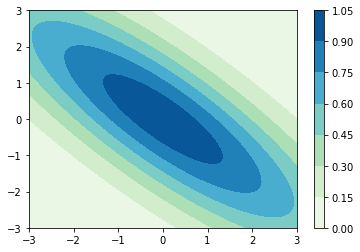

In [238]:
n_points = 100

x = np.linspace(-3, 3, n_points)
y = np.linspace(-3, 3, n_points)
grid = np.meshgrid(x, y)
xys = np.stack(grid).reshape(2, n_points ** 2).T

z = gaussian2d(xys, *normal_dist_params)

plt.contourf(x, y, z.reshape(100, 100), cmap='GnBu')
plt.gca().set_aspect('auto')
plt.colorbar()

In [239]:
from flonacomldft.gaussian_utils import MoG

In [240]:
means, cov, A = from_popt_to_gauss_params(normal_dist_params)

means =  torch.tensor(means)
cov = torch.tensor(cov)

#target_flo = MoG([means], [cov])

In [241]:
from flonacomldft.utils.io_utils import get_path
import numpy as np
from scipy.optimize import curve_fit
from ase.units import kB

file = get_path()+'/unrotated_300.txt'

In [242]:
# There is a better way to do this for sure

C_line = np.loadtxt(file, usecols=0)
R_line = np.loadtxt(file, usecols=1)
F_line = np.loadtxt(file, usecols=2)

bins = 401

C_grid = C_line.reshape(bins, bins)
R_grid = R_line.reshape(bins, bins)
F_grid = F_line.reshape(bins, bins)

T = 300
P_line = np.exp(-F_line/(kB*T))
P_grid = P_line.reshape(bins, bins)

xrange_is0 = [290,370]
yrange_is0 = [90,190]

C_is0 = C_grid[xrange_is0[0]:xrange_is0[1], yrange_is0[0]:yrange_is0[1]]
R_is0 = R_grid[xrange_is0[0]:xrange_is0[1], yrange_is0[0]:yrange_is0[1]]
F_is0 = F_grid[xrange_is0[0]:xrange_is0[1], yrange_is0[0]:yrange_is0[1]]
P_is0 = P_grid[xrange_is0[0]:xrange_is0[1], yrange_is0[0]:yrange_is0[1]]

xrange_is1 = [150,220]
yrange_is1 = [170,275]

C_is1 = C_grid[xrange_is1[0]:xrange_is1[1], yrange_is1[0]:yrange_is1[1]]
R_is1 = R_grid[xrange_is1[0]:xrange_is1[1], yrange_is1[0]:yrange_is1[1]]
F_is1 = F_grid[xrange_is1[0]:xrange_is1[1], yrange_is1[0]:yrange_is1[1]]
P_is1 = P_grid[xrange_is1[0]:xrange_is1[1], yrange_is1[0]:yrange_is1[1]]

C_is0_line = C_is0.reshape(-1)
R_is0_line = R_is0.reshape(-1)
F_is0_line = F_is0.reshape(-1)
P_is0_line = P_is0.reshape(-1)

C_is1_line = C_is1.reshape(-1)
R_is1_line = R_is1.reshape(-1)
F_is1_line = F_is1.reshape(-1)
P_is1_line = P_is1.reshape(-1)

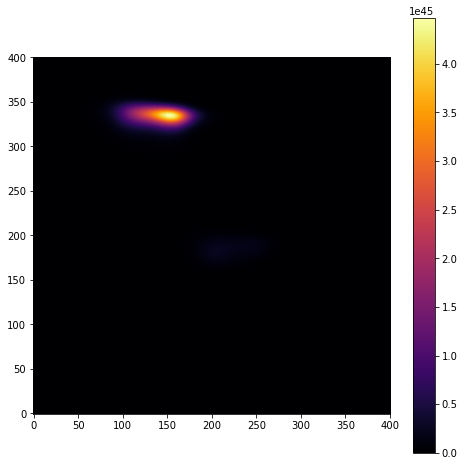

In [243]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
im = ax.imshow(P_grid, cmap='inferno', origin='lower')
fig.colorbar(im)

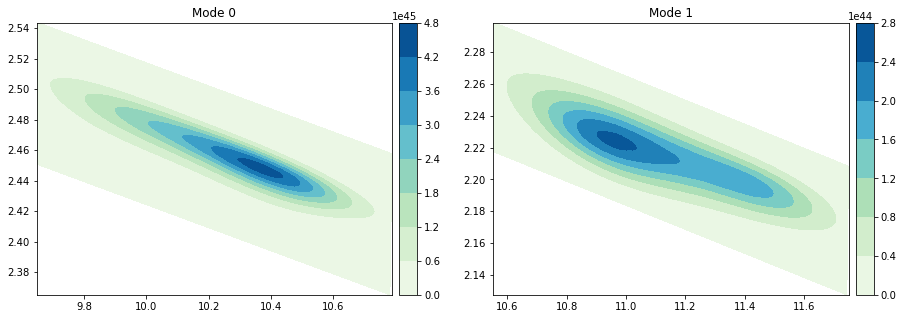

In [244]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

im0 = axs[0].contourf(C_is0, R_is0, P_is0, cmap='GnBu')
axs[0].set_title('Mode 0')

divider = make_axes_locatable(axs[0])
cax = divider.append_axes('right', size='5%', pad=0.1)
fig.colorbar(im0, cax=cax, orientation='vertical')

im1 = axs[1].contourf(C_is1, R_is1, P_is1, cmap='GnBu')
axs[1].set_title('Mode 1')
divider = make_axes_locatable(axs[1])
cax = divider.append_axes('right', size='5%', pad=0.1)
fig.colorbar(im1, cax=cax, orientation='vertical');

plt.gca().set_aspect('auto')

/tmp/ipykernel_569740/331833441.py:25: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ax[0].contour(x, y, z.reshape(n_points, n_points), colors='k', linestyle='--', linewidths=0.3)


(array([ 1.01042889e+01,  2.45902629e+00,  7.27262065e-01,  7.77966355e+02,
        -7.63838456e+02,  8.37710117e+01,  2.71285222e+00]),
 (array([10.10428892,  2.45902629]),
  array([[ 1.40957083e-04, -1.30904313e-03],
         [ 1.28527086e-03,  1.22372569e-06]]),
  2.7128522164032383))

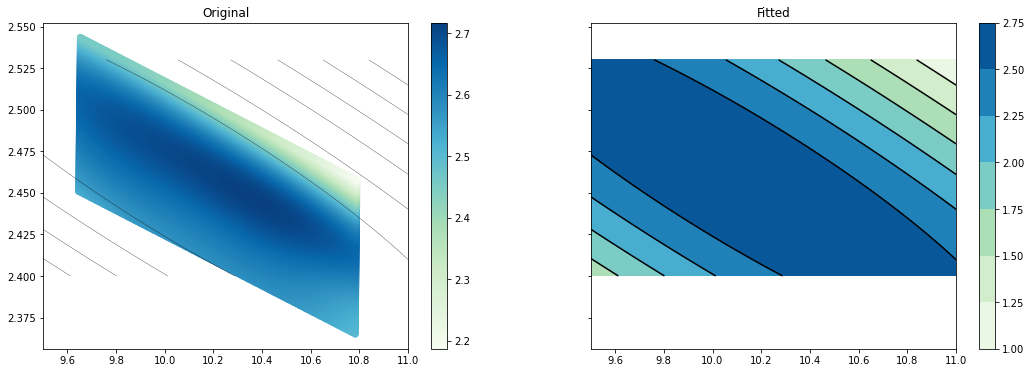

In [253]:
#data = np.stack([C_line[ind], R_line[ind], P_line[ind]], axis=1)
P_is0_line = -F_is0_line
data = np.stack([C_is0_line, R_is0_line, P_is0_line], axis=1)
#data = np.stack([C_is0_line[ind_is0], R_is0_line[ind_is0], P_is0_line[ind_is0]], axis=1)

xy = data[:, :2]
z = data[:, 2]

#params = np.array([10.4, 2.4, 51, 0, -200.0, 5952, 1e45]) #THIS PARAMETERS FIT THE gaussian2d but covmatrix is non-positive
params = np.array([10.4, 2.4, 50, 1000, 1000, 5000, 1e45])

popt_0, pcov_0 = curve_fit(gaussian2d, xy, z, params)

n_points = 100
x = np.linspace(9.5, 11, n_points)
y = np.linspace(2.4, 2.53, n_points)
grid = np.meshgrid(x, y)
xys = np.stack(grid).reshape(2, n_points ** 2).T

z = gaussian2d(xys, *popt_0)

fig, ax = plt.subplots(1, 2, figsize=(18, 6), sharex=True, sharey=True)
#ax[0].scatter(C_line[ind], R_line[ind], c=P_line[ind], cmap='GnBu')
ax[0].scatter(C_is0_line, R_is0_line, c=P_is0_line, cmap='GnBu')
ax[0].contour(x, y, z.reshape(n_points, n_points), colors='k', linestyle='--', linewidths=0.3)
fig.colorbar(ax[0].scatter(C_is0_line, R_is0_line, c=P_is0_line, cmap='GnBu'), ax=ax[0])
ax[0].set_title('Original')

ax[1].contourf(x, y, z.reshape(n_points, n_points), cmap='GnBu') 
ax[1].contour(x, y, z.reshape(n_points, n_points), colors='k')
ax[1].set_title('Fitted')
fig.colorbar(ax[1].contourf(x, y, z.reshape(n_points, n_points), cmap='GnBu'), ax=ax[1])

popt_0, from_popt_to_gauss_params(popt_0)

In [246]:
def gaussian2d(XY, x0, y0, sigma_xx, sigma_xy, sigma_yx, sigma_yy, A):
    XY = XY.T
    XY = torch.tensor(XY, dtype=torch.float64, device=device)
    dx = XY[0] - x0
    dy = XY[1] - y0
    covariance_xx = sigma_xx * dx
    covariance_xy = sigma_xy * dx
    covariance_yx = sigma_yx * dy
    covariance_yy = sigma_yy * dy
    exponent = -0.5 * (covariance_xx * dx + covariance_xy * dy + covariance_yx * dx + covariance_yy * dy)
    return A * torch.exp(exponent)

class TargetGaussian:
    def __init__(self, mean, cov, norm, kB=kB, T=300):
        self.kB = kB
        self.T = T
        self.norm = norm
        self.mean = mean
        self.cov = cov
        self.inv_cov = np.linalg.inv(cov)
        self.popt = np.hstack([self.mean.flatten(), self.inv_cov.flatten(), self.norm])
    
    def sample(self, n_samples):
        samples = np.random.multivariate_normal(self.mean, self.cov, n_samples)
        return torch.tensor(samples, dtype=torch.float64)

    def prob(self, x):
        return torch.tensor(gaussian2d(x, *self.popt)).detach()

    def log_prob(self, x):
        return torch.log(gaussian2d(x, *self.popt)).detach()
    
    def U(self, x):
        return -self.log_prob(x)*(self.T*self.kB)

In [247]:
popt_vert = np.array([10.27, 2.45, 500, -10, 10000, 500, 4e45])
mean_vert, cov_vert, norm_vert = from_popt_to_gauss_params(popt_vert)

A = 1/15349329
a = 140/1705481
#b = 6821/15349329 #also works
#c = -781/1705481 #also works
b = 4821/15349329
c = -581/1705481
d = 961/15349329

cov_vert  = np.array([[a, b], [c, d]])
vert = TargetGaussian(mean_vert, cov_vert, norm_vert)

mean_0, cov_0, norm_0 = from_popt_to_gauss_params(popt_0)

#cov_0[1, 0] = 0
#cov_0[0, 1] = cov_0[0, 0]
#cov_0[0, 0] = cov_0[1, 1]
#cov_0[1, 1] = cov_0[0, 1]
#cov_0[0, 1] = 0

target_0 = TargetGaussian(mean_0, cov_0, norm_0)

/tmp/ipykernel_569740/976122888.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/matplotlib/contour.py:1491: UserWarning: Warning: converting a masked element to nan.
  self.zmax = float(z.max())
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/matplotlib/contour.py:1492: UserWarning: Warning: converting a masked element to nan.
  self.zmin = float(z.min())
/tmp/ipykernel_569740/976122888.py:24: RuntimeWarning: covariance is not positive-semidefinite.
  samples = np.random.multivariate_normal(self.mean, self.cov, n_samples)
/tmp/ipykernel_569740/976122888.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().de

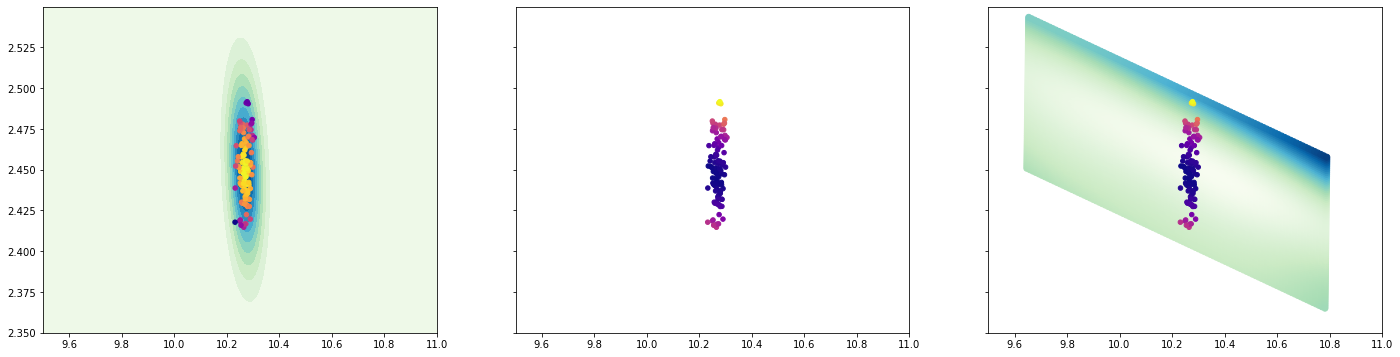

In [248]:
lims = {'x_min':9.5, 'x_max':11., 'y_min':2.35, 'y_max':2.55}
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_plot(ax, n_points, target_log_prob, prop_log_prob=None, lims=lims):
    
    x_range = torch.linspace(lims['x_min'], lims['x_max'], n_points, device=device)

    if lims['y_min'] is None:
        y_range = x_range.clone()
    else:
        y_range = torch.linspace(lims['y_min'], lims['y_max'], n_points, device=device)

    grid = torch.meshgrid(x_range, y_range)
    xys = torch.stack(grid).reshape(2, n_points ** 2).T.to(device)

    Us_target = target_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

    if ax is None:
        plt.figure()
    else:
        plt.sca(ax)
    #plt.axis('off')

    plt.contourf(x_range, y_range, np.exp(Us_target)
    # np.log( - Us_target + Us_target.max() + 1)
    , 10, cmap='GnBu')
    ax.set_aspect('equal')

    if prop_log_prob is not None:
        Us_prop = prop_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

        plt.contour(x_range, y_range, np.exp(Us_prop), 10, colors='k', linestyles=':', alpha=0.5)

fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(24, 6))
ax = [ax] 
set_plot(ax[0][0], 1000, vert.log_prob, None, lims)
plt.gca().set_aspect('auto')
set_plot(ax[0][1], 1000, target_0.log_prob, None, lims)
plt.gca().set_aspect('auto')

ax[0][2].scatter(C_is0_line, R_is0_line, c=P_is0_line, cmap='GnBu')

samples_vert = vert.sample(100)
samples_0 = target_0.sample(1000)

ax[0][0].scatter(samples_vert[:, 0], samples_vert[:, 1], c=vert.prob(samples_vert), cmap='plasma', s=20)
ax[0][1].scatter(samples_vert[:, 0], samples_vert[:, 1], c=target_0.prob(samples_vert), cmap='plasma', s=20)
ax[0][2].scatter(samples_vert[:, 0], samples_vert[:, 1], c=target_0.prob(samples_vert), cmap='plasma', s=20)

In [249]:
popt_gen = np.array([10.27, 2.45, 500, -10, 10000, 500, 4e45])
mean_gen, cov_gen, norm_gen = from_popt_to_gauss_params(popt_gen)

samples_generator = TargetGaussian(mean_gen, cov_gen, norm_gen)


/tmp/ipykernel_569740/976122888.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)
/tmp/ipykernel_569740/976122888.py:24: RuntimeWarning: covariance is not positive-semidefinite.
  samples = np.random.multivariate_normal(self.mean, self.cov, n_samples)
/tmp/ipykernel_569740/976122888.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(gaussian2d(x, *self.popt)).detach()


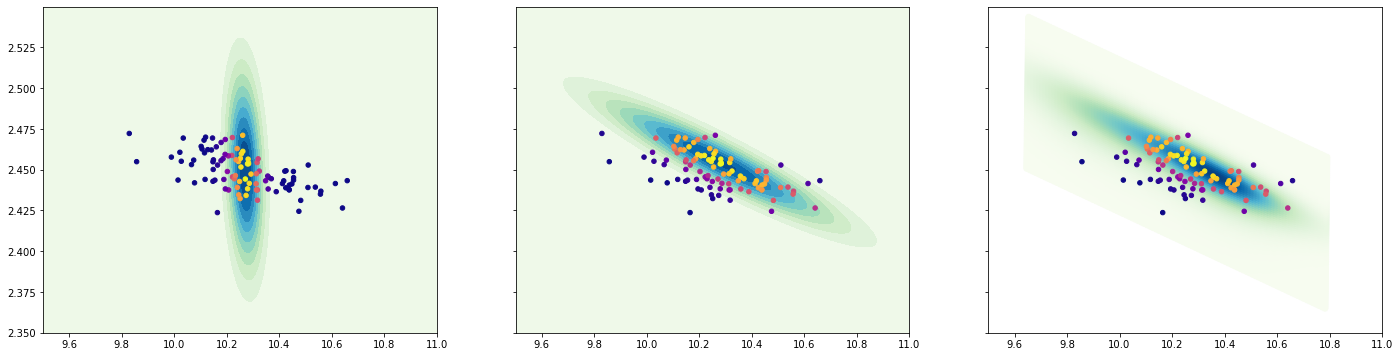

In [18]:
fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(24, 6))

set_plot(ax[0], 1000, vert.log_prob, None, lims)
plt.gca().set_aspect('auto')

set_plot(ax[1], 1000, target_0.log_prob, None, lims)
plt.gca().set_aspect('auto')

ax[2].scatter(C_is0_line, R_is0_line, c=P_is0_line, cmap='GnBu')

samples_gen = samples_generator.sample(100)
samples_0 = target_0.sample(1000)

ax[0].scatter(samples_gen[:, 0], samples_gen[:, 1], c=vert.prob(samples_gen), cmap='plasma', s=20)
ax[1].scatter(samples_gen[:, 0], samples_gen[:, 1], c=target_0.prob(samples_gen), cmap='plasma', s=20)
ax[2].scatter(samples_gen[:, 0], samples_gen[:, 1], c=target_0.prob(samples_gen), cmap='plasma', s=20)

In [19]:
popts_0 = [target_0.popt, vert.popt, samples_generator.popt]
popts_0

[array([ 1.02780425e+01,  2.45467097e+00,  9.61212303e+01,  4.49457582e+04,
        -4.28999489e+04,  1.26042674e+04,  4.09510568e+45]),
 array([ 1.02700000e+01,  2.45000000e+00,  5.58318634e+02, -2.80088880e+03,
         3.03792730e+03,  7.32030675e+02,  4.00000000e+45]),
 array([ 1.027e+01,  2.450e+00,  5.000e+02, -1.000e+01,  1.000e+04,
         5.000e+02,  4.000e+45])]

In [20]:
from flonacomldft.utils.io_utils import get_path
get_path()

'/mnt/home/amolina/ceph/ml-dft/database'

In [21]:
popts_0 = [target_0.popt, vert.popt, samples_generator.popt]
print(popts_0)

np.save(get_path()+'/params_fit_fes/mode_0.npy', popts_0)

/tmp/ipykernel_569740/3385827430.py:23: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ax[0].contour(x, y, z.reshape(n_points, n_points), colors='k', linestyle='--', linewidths=0.3)


array([ 1.10999248e+01,  2.21658995e+00,  3.60076470e+01,  1.21366577e+03,
       -4.28407082e+02,  5.76850984e+03,  2.43703223e+44])

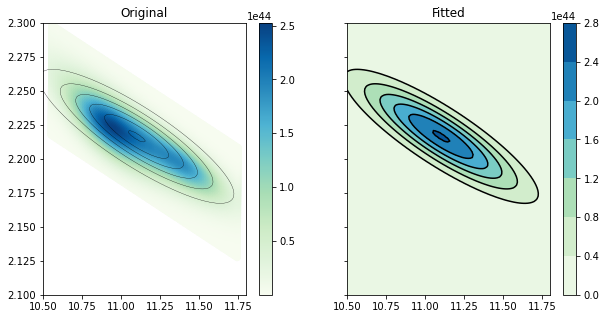

In [22]:
#data = np.stack([C_line[ind], R_line[ind], P_line[ind]], axis=1)
data = np.stack([C_is1_line, R_is1_line, P_is1_line], axis=1)

xy = data[:, :2]
z = data[:, 2]

#params = np.array([11.1, 2.2, 18, 0.0, 196.0, 2884, 2e44])
params = np.array([11.1, 2.2, 100, 80, -96.0, 884, 2e44])

popt_1, pcov_1 = curve_fit(gaussian2d, xy, z, params)

n_points = 100
x = np.linspace(10.5, 11.8, n_points)
y = np.linspace(2.1, 2.3, n_points)
grid = np.meshgrid(x, y)
xys = np.stack(grid).reshape(2, n_points ** 2).T

z = np.array([gaussian2d(xy, *popt_1) for xy in xys])

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
#ax[0].scatter(C_line[ind], R_line[ind], c=P_line[ind], cmap='GnBu')
ax[0].scatter(C_is1_line, R_is1_line, c=P_is1_line, cmap='GnBu')
ax[0].contour(x, y, z.reshape(n_points, n_points), colors='k', linestyle='--', linewidths=0.3)
fig.colorbar(ax[0].scatter(C_is1_line, R_is1_line, c=P_is1_line, cmap='GnBu'), ax=ax[0])

ax[0].set_title('Original')

ax[1].contourf(x, y, z.reshape(n_points, n_points), cmap='GnBu') 
ax[1].contour(x, y, z.reshape(n_points, n_points), colors='k')
ax[1].set_title('Fitted')
fig.colorbar(ax[1].contourf(x, y, z.reshape(n_points, n_points), cmap='GnBu'), ax=ax[1])

popt_1

In [23]:
popt_vert = np.array([11.01, 2.21, 500, -10, 10000, 500, 2.5e45])
mean_vert, cov_vert, norm_vert = from_popt_to_gauss_params(popt_vert)

#A = 1/15349329
#a = 140/1705481
#b = 6821/15349329 #also works
#c = -781/1705481 #also works
#b = 4821/15349329
#c = -581/1705481
#d = 961/15349329

cov_vert  = np.array([[a, b], [c, d]])
vert = TargetGaussian(mean_vert, cov_vert, norm_vert)

mean_1, cov_1, norm_1 = from_popt_to_gauss_params(popt_1)

#cov_0[1, 0] = 0
#cov_0[0, 1] = cov_0[0, 0]
#cov_0[0, 0] = cov_0[1, 1]
#cov_0[1, 1] = cov_0[0, 1]
#cov_0[0, 1] = 0

target_1 = TargetGaussian(mean_1, cov_1, norm_1)

/tmp/ipykernel_569740/976122888.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)
/tmp/ipykernel_569740/976122888.py:24: RuntimeWarning: covariance is not positive-semidefinite.
  samples = np.random.multivariate_normal(self.mean, self.cov, n_samples)
/tmp/ipykernel_569740/976122888.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(gaussian2d(x, *self.popt)).detach()


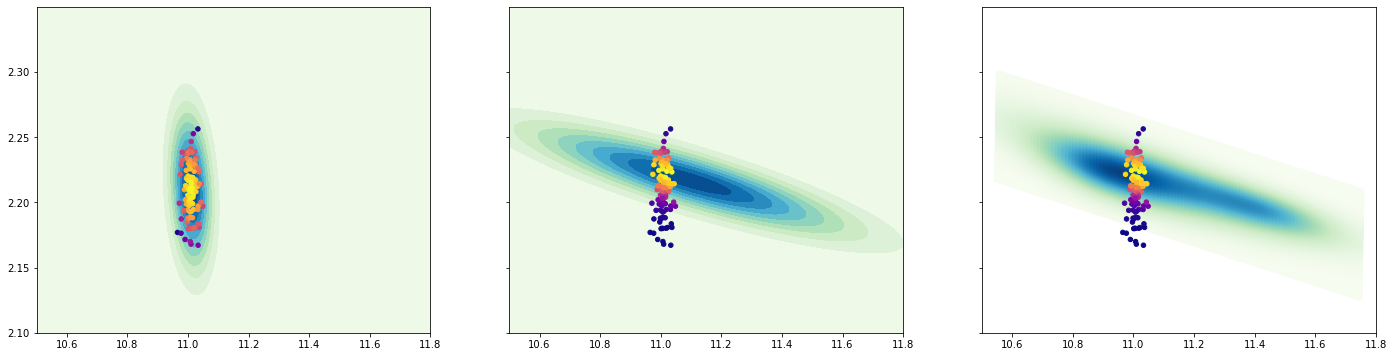

In [29]:
lims = {'x_min':10.5, 'x_max':11.8, 'y_min':2.1, 'y_max':2.35}

fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(24, 6))

set_plot(ax[0], 1000, vert.log_prob, None, lims)
plt.gca().set_aspect('auto')
set_plot(ax[1], 1000, target_1.log_prob, None, lims)
plt.gca().set_aspect('auto')

ax[2].scatter(C_is1_line, R_is1_line, c=P_is1_line, cmap='GnBu')

samples_vert = vert.sample(100)
samples_1 = target_1.sample(1000)

ax[0].scatter(samples_vert[:, 0], samples_vert[:, 1], c=vert.prob(samples_vert), cmap='plasma', s=20)
ax[1].scatter(samples_vert[:, 0], samples_vert[:, 1], c=target_1.prob(samples_vert), cmap='plasma', s=20)
ax[2].scatter(samples_vert[:, 0], samples_vert[:, 1], c=target_1.prob(samples_vert), cmap='plasma', s=20)

In [70]:
popt_gen = np.array([11.01, 2.216, 50, -250, 1000, 500, 4e45])
mean_gen, cov_gen, norm_gen = from_popt_to_gauss_params(popt_gen)

samples_generator = TargetGaussian(mean_gen, cov_gen, norm_gen)

/tmp/ipykernel_569740/976122888.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)
/tmp/ipykernel_569740/976122888.py:24: RuntimeWarning: covariance is not positive-semidefinite.
  samples = np.random.multivariate_normal(self.mean, self.cov, n_samples)
/tmp/ipykernel_569740/976122888.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(gaussian2d(x, *self.popt)).detach()


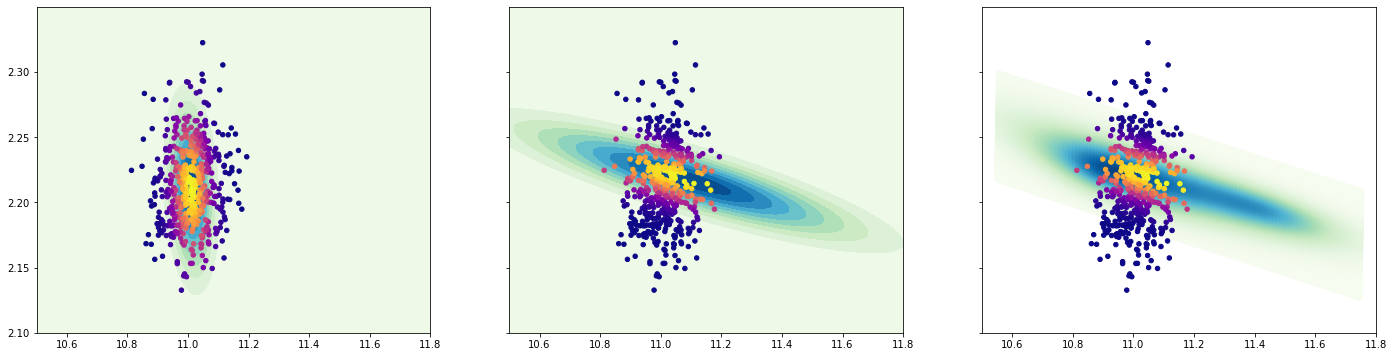

In [71]:
fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(24, 6))

set_plot(ax[0], 1000, vert.log_prob, None, lims)
plt.gca().set_aspect('auto')

set_plot(ax[1], 1000, target_1.log_prob, None, lims)
plt.gca().set_aspect('auto')

ax[2].scatter(C_is1_line, R_is1_line, c=P_is1_line, cmap='GnBu')

samples_gen = samples_generator.sample(500)
#samples_1 = target_1.sample(1000)

ax[0].scatter(samples_gen[:, 0], samples_gen[:, 1], c=vert.prob(samples_gen), cmap='plasma', s=20)
ax[1].scatter(samples_gen[:, 0], samples_gen[:, 1], c=target_1.prob(samples_gen), cmap='plasma', s=20)
ax[2].scatter(samples_gen[:, 0], samples_gen[:, 1], c=target_1.prob(samples_gen), cmap='plasma', s=20)

In [ ]:
popts_1 = [target_1.popt, vert.popt, samples_generator.popt]
print(popts_1)

np.save(get_path()+'/params_fit_fes/mode_1.npy', popts_1)

In [ ]:
# Find a better thing to propose samples

In [72]:
from torch.distributions import MultivariateNormal

In [74]:
mean_0 = torch.tensor(mean_0)
cov_0 = torch.tensor(cov_0)

In [81]:
import torch
from torch.distributions import MultivariateNormal
import torch.optim as optim
import matplotlib.pyplot as plt

dim = 3


mean_true = torch.zeros(dim, device="cpu")
cov_true = torch.tensor(
    [[1.0, 0.9, 0.1], [0.9, 2.0, 0.0], [0.1, 0.0, 1.0]], device="cpu"
)

mvn_true = MultivariateNormal(mean_true, cov_true)

train_samples = mvn_true.sample((1000,))
val_samples = mvn_true.sample((1000,))

In [82]:
mean = torch.zeros(dim, device="cpu")
cov = torch.eye(dim, requires_grad=True, device="cpu")


optimizer = optim.SGD([cov], lr=0.001, momentum=0.01, weight_decay=0)

mvn = MultivariateNormal(
    loc=mean,
    scale_tril=cov,
)

train_losses = []
val_losses = []

for i in range(10000):
    optimizer.zero_grad()
    loss = -mvn.log_prob(train_samples.cpu()).mean()
    loss.backward()
    optimizer.step()

# plt.plot(train_losses, label="train")
# plt.plot(val_losses,  label="val")
# plt.legend()
print(cov_true)
print()
print(cov)
print()
print(torch.linalg.cholesky(torch.cov(train_samples.cpu().T)))

tensor([[1.0000, 0.9000, 0.1000],
        [0.9000, 2.0000, 0.0000],
        [0.1000, 0.0000, 1.0000]])

tensor([[ 1.0044,  0.0000,  0.0000],
        [ 0.9299,  1.0845,  0.0000],
        [ 0.1468, -0.1033,  0.9973]], requires_grad=True)

tensor([[ 1.0054,  0.0000,  0.0000],
        [ 0.9322,  1.0850,  0.0000],
        [ 0.1462, -0.1033,  0.9968]])


In [118]:
cov_0.T

tensor([[ 6.5328e-06,  2.2235e-05],
        [-2.3295e-05,  4.9820e-08]], dtype=torch.float64)

In [177]:
dim = 2

mean = torch.zeros(dim, device="cpu")
cov = torch.eye(dim, requires_grad=True, device="cpu") #+ 0.5*torch.eye(dim, requires_grad=True, device="cpu")

mean = mean_0.clone()
#cov = cov_0.clone().T
#cov[1,0] = cov[0, 1]

mvn = MultivariateNormal(
    loc=mean,
    scale_tril=cov,
)

data = torch.tensor([C_is0_line, R_is0_line]).T #from array to tensor its better


optimizer = optim.SGD([cov], lr=0.0001, momentum=0.001, weight_decay=0)

y_true = torch.from_numpy(-F_is0_line)

train_losses = []
val_losses = []

for i in range(10000):
    optimizer.zero_grad()
    loss = ((mvn.log_prob(data)-y_true)**2).mean()
    if i%1000==0:
        print(i, loss.item())
    loss.backward()
    optimizer.step()
    
#print(cov)
#print()
#print(torch.linalg.cholesky(torch.cov(train_samples.cpu().T)))

0 20.275220388855203
1000 0.8794046953817953
2000 0.8520852866716636
3000 0.8518353230604441
4000 0.8518348806751342
5000 0.8518349888162452
6000 0.8518349888162452
7000 0.8518349888162452
8000 0.8518349888162452
9000 0.8518349888162452


In [178]:
#for i in range(10000):
#    optimizer.zero_grad()
#    loss = ((mvn.log_prob(data)-y_true)**2).mean()
#    if i%100:
#        print(i, loss)
#    loss.backward()
#    optimizer.step()

In [179]:
cov, mvn.covariance_matrix

(tensor([[ 0.3949,  0.0000],
         [-0.0286,  0.0320]], requires_grad=True),
 tensor([[ 0.1559, -0.0113],
         [-0.0113,  0.0018]], grad_fn=<ExpandBackward0>))

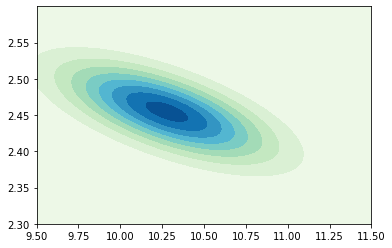

In [180]:
lims = {'x_min':9.5, 'x_max':11.5, 'y_min':2.3, 'y_max':2.6}

fig, ax = plt.subplots()
set_plot(ax, 100, mvn.log_prob, None, lims)
plt.gca().set_aspect('auto')

In [210]:
# mvn.sample((10,))

In [197]:
mvn.covariance_matrix, mvn.mean

(tensor([[ 0.1559, -0.0113],
         [-0.0113,  0.0018]], grad_fn=<ExpandBackward0>),
 tensor([10.2780,  2.4547], dtype=torch.float64))

In [209]:
torch.linalg.inv(mvn.covariance_matrix)

tensor([[ 11.5363,  70.8364],
        [ 70.8364, 979.3252]], grad_fn=<LinalgInvExBackward0>)

In [202]:
target = MoG([mvn.mean.to(torch.float)], [mvn.covariance_matrix.to(torch.float)])

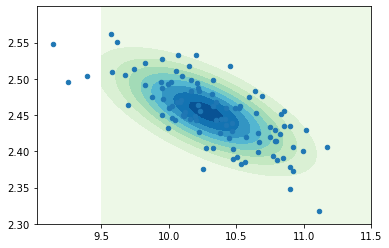

In [206]:
lims = {'x_min':9.5, 'x_max':11.5, 'y_min':2.3, 'y_max':2.6}

fig, ax = plt.subplots()
set_plot(ax, 100, mvn.log_prob, None, lims)
samples = target.sample(100)

ax.scatter(samples[:, 0].detach().numpy(), samples[:, 1].detach().numpy(), cmap='plasma', s=20)
plt.gca().set_aspect('auto')